# Task 3: Database Engineering

**Objective:** Store cleaned and analyzed review data in a PostgreSQL database and verify data integrity using SQL queries.

**Database:** `bank_reviews`  
**Tables:** `banks`, `reviews`  
**Tool:** psycopg2

## Setup

Before running this notebook, ensure:
1. PostgreSQL is installed and running
2. The `bank_reviews` database and `bank_admin` user are created
3. `data/clean/reviews_final.csv` exists

Run in psql to set up:
```sql
CREATE DATABASE bank_reviews;
CREATE USER bank_admin WITH PASSWORD 'admin123';
GRANT ALL PRIVILEGES ON DATABASE bank_reviews TO bank_admin;
\c bank_reviews
GRANT CREATE ON SCHEMA public TO bank_admin;
```

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.db_insert import get_connection, create_tables, insert_banks, insert_reviews, DB_CONFIG, BANKS
from scripts.db_queries import run_query

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Data

In [2]:
df = pd.read_csv("../data/clean/reviews_final.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nReviews per bank:")
print(df["bank"].value_counts())
df.head()

Shape: (1800, 11)

Columns: ['review_id', 'review', 'rating', 'date', 'bank', 'source', 'vader_score', 'vader_label', 'distilbert_label', 'distilbert_score', 'identified_theme']

Reviews per bank:
bank
Commercial Bank of Ethiopia    600
Bank of Abyssinia              600
Dashen Bank                    600
Name: count, dtype: int64


,review_id,review,rating,date,bank,source,vader_score,vader_label,distilbert_label,distilbert_score,identified_theme
0,1,it's a good application,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999866,Positive Experience
1,2,thank you cbe,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.3612,positive,positive,0.999756,Positive Experience
2,3,is good,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999839,Positive Experience
3,4,wow,5,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.5859,positive,positive,0.999592,Other
4,5,Good application,2,2026-05-13,Commercial Bank of Ethiopia,Google Play,0.4404,positive,positive,0.999855,Positive Experience


## 2. Database Connection & Table Creation

Connecting to `bank_reviews` as `bank_admin` and creating the `banks` and `reviews` tables if they don't already exist.

In [3]:
conn = get_connection()
create_tables(conn)

[DB] Connected to bank_reviews successfully.
[DB] Tables created successfully.


## 3. Data Insertion

Inserting 3 banks into the `banks` table, then inserting all 1,800 reviews into the `reviews` table. `ON CONFLICT DO NOTHING` makes this safe to re-run.

In [4]:
bank_id_map = insert_banks(conn)
print(f"\nBank ID map: {bank_id_map}")

[DB] Inserted 3 banks.

Bank ID map: {'Commercial Bank of Ethiopia': 1, 'Bank of Abyssinia': 2, 'Dashen Bank': 3}


In [5]:
insert_reviews(conn, df, bank_id_map)

Inserting reviews: 100%|██████████| 1800/1800 [00:01<00:00, 1250.73it/s]

[DB] Inserted: 1800 | Skipped: 0


## 4. Verification Queries

Running SQL queries to confirm data integrity — counts, averages, null checks, and distributions.

In [6]:
# 1. Total reviews per bank
q1 = run_query(conn, "Total Reviews per Bank", """
    SELECT b.bank_name, COUNT(r.review_id) AS total_reviews
    FROM banks b
    LEFT JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name
    ORDER BY total_reviews DESC;
""")


Total Reviews per Bank
                  bank_name  total_reviews
Commercial Bank of Ethiopia            600
                Dashen Bank            600
          Bank of Abyssinia            600


In [7]:
# 2. Average rating per bank
q2 = run_query(conn, "Average Rating per Bank", """
    SELECT
        b.bank_name,
        ROUND(AVG(r.rating)::NUMERIC, 2) AS avg_rating,
        MIN(r.rating) AS min_rating,
        MAX(r.rating) AS max_rating
    FROM banks b
    LEFT JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name
    ORDER BY avg_rating DESC;
""")


Average Rating per Bank
                  bank_name avg_rating  min_rating  max_rating
Commercial Bank of Ethiopia       4.12           1           5
                Dashen Bank       3.93           1           5
          Bank of Abyssinia       3.51           1           5


In [8]:
# 3. Sentiment distribution per bank
q3 = run_query(conn, "Sentiment Distribution per Bank", """
    SELECT
        b.bank_name,
        r.sentiment_label,
        COUNT(*) AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY b.bank_name), 1) AS percentage
    FROM banks b
    JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name, r.sentiment_label
    ORDER BY b.bank_name, count DESC;
""")


Sentiment Distribution per Bank
                  bank_name sentiment_label  count percentage
          Bank of Abyssinia        positive    323       53.8
          Bank of Abyssinia        negative    277       46.2
Commercial Bank of Ethiopia        positive    422       70.3
Commercial Bank of Ethiopia        negative    178       29.7
                Dashen Bank        positive    399       66.5
                Dashen Bank        negative    201       33.5


In [9]:
# 4. Null check
q4 = run_query(conn, "Null Check on Key Columns", """
    SELECT
        COUNT(*) FILTER (WHERE review_text IS NULL)     AS null_review_text,
        COUNT(*) FILTER (WHERE rating IS NULL)          AS null_rating,
        COUNT(*) FILTER (WHERE sentiment_label IS NULL) AS null_sentiment_label,
        COUNT(*) FILTER (WHERE sentiment_score IS NULL) AS null_sentiment_score,
        COUNT(*) FILTER (WHERE identified_theme IS NULL) AS null_theme,
        COUNT(*) FILTER (WHERE review_date IS NULL)     AS null_review_date
    FROM reviews;
""")


Null Check on Key Columns
 null_review_text  null_rating  null_sentiment_label  null_sentiment_score  null_theme  null_review_date
                0            0                     0                     0           0                 0


In [10]:
# 5. Average sentiment score per bank
q5 = run_query(conn, "Average Sentiment Score per Bank", """
    SELECT
        b.bank_name,
        ROUND(AVG(r.sentiment_score)::NUMERIC, 4) AS avg_sentiment_score
    FROM banks b
    JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name
    ORDER BY avg_sentiment_score DESC;
""")


Average Sentiment Score per Bank
                  bank_name avg_sentiment_score
Commercial Bank of Ethiopia              0.4123
                Dashen Bank              0.3327
          Bank of Abyssinia              0.0862


In [11]:
# 6. Reviews per bank per star rating
q6 = run_query(conn, "Reviews per Bank per Star Rating", """
    SELECT b.bank_name, r.rating, COUNT(*) AS count
    FROM banks b
    JOIN reviews r ON b.bank_id = r.bank_id
    GROUP BY b.bank_name, r.rating
    ORDER BY b.bank_name, r.rating;
""")


Reviews per Bank per Star Rating
                  bank_name  rating  count
          Bank of Abyssinia       1    183
          Bank of Abyssinia       2     22
          Bank of Abyssinia       3     27
          Bank of Abyssinia       4     40
          Bank of Abyssinia       5    328
Commercial Bank of Ethiopia       1     89
Commercial Bank of Ethiopia       2     15
Commercial Bank of Ethiopia       3     38
Commercial Bank of Ethiopia       4     52
Commercial Bank of Ethiopia       5    406
                Dashen Bank       1    115
                Dashen Bank       2     24
                Dashen Bank       3     33
                Dashen Bank       4     42
                Dashen Bank       5    386


## 5. Query Result Visualizations

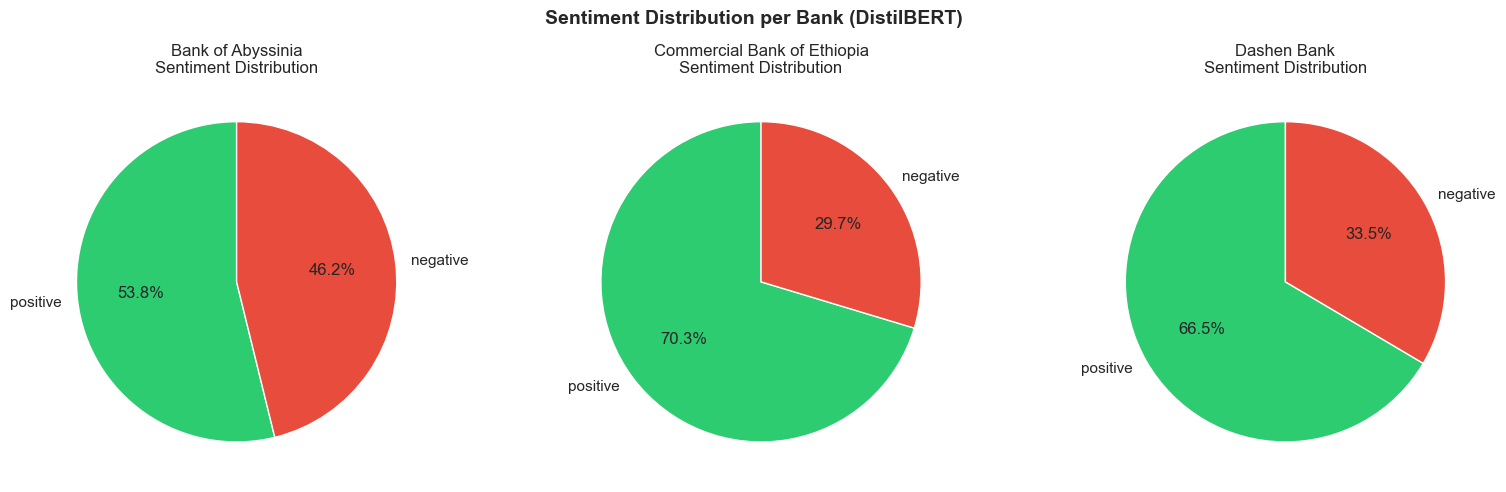

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sentiment distribution
for i, bank in enumerate(q3["bank_name"].unique()):
    bank_data = q3[q3["bank_name"] == bank]
    axes[i].pie(
        bank_data["count"],
        labels=bank_data["sentiment_label"],
        autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
        startangle=90
    )
    axes[i].set_title(f"{bank}\nSentiment Distribution")

plt.suptitle("Sentiment Distribution per Bank (DistilBERT)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

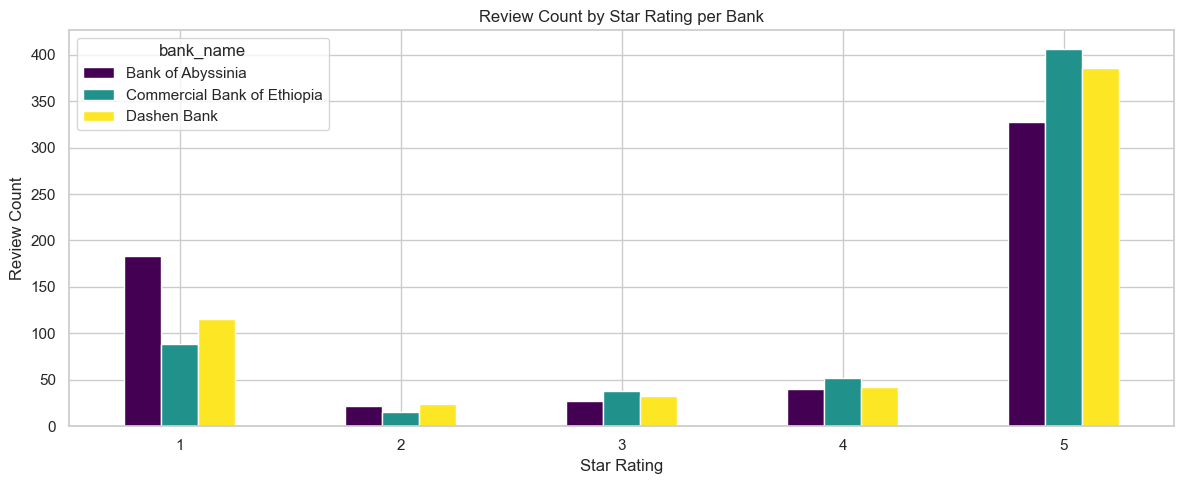

In [13]:
# Rating distribution per bank
rating_pivot = q6.pivot(index="rating", columns="bank_name", values="count")
rating_pivot.plot(kind="bar", figsize=(12, 5), colormap="viridis")
plt.title("Review Count by Star Rating per Bank")
plt.xlabel("Star Rating")
plt.ylabel("Review Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Close Connection

In [14]:
conn.close()
print("[DB] Connection closed.")

[DB] Connection closed.
